In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
# Import full_charging_df from feather file 
full_charging_df = pd.read_feather("../data/full_charging_df.feather")
full_charging_df

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected,siteType
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944,Private
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974,Private
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610,Private
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481,Private
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928,Private
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65032,5d2fbdd3f9af8b4d0dd0d54a,2019-07-01 14:49:12-07:00,2019-07-01 18:37:18-07:00,2019-07-01 16:14:33-07:00,8.399,1_1_179_798_2019-07-01 21:49:11.873404,1,AG-3F18,1-1-179-798,America/Los_Angeles,...,Monday,2019,False,14,18,16.0,85.350000,228.100000,0.374178,Private
65033,5d2fbdd3f9af8b4d0dd0d54b,2019-07-01 14:58:45-07:00,2019-07-01 17:39:48-07:00,2019-07-01 17:40:21-07:00,16.864,1_1_179_794_2019-07-01 21:58:44.571011,1,AG-3F20,1-1-179-794,America/Los_Angeles,...,Monday,2019,False,14,17,17.0,161.600000,161.050000,1.003415,Private
65034,5d2fbdd3f9af8b4d0dd0d54c,2019-07-01 15:02:21-07:00,2019-07-01 17:58:50-07:00,2019-07-01 17:59:23-07:00,18.335,1_1_191_807_2019-07-01 22:02:20.810735,1,AG-4F47,1-1-191-807,America/Los_Angeles,...,Monday,2019,False,15,17,17.0,177.033333,176.483333,1.003116,Private
65035,5d2fbdd3f9af8b4d0dd0d54d,2019-07-01 15:23:44-07:00,2019-07-01 19:03:36-07:00,2019-07-01 19:04:06-07:00,22.815,1_1_179_781_2019-07-01 22:23:32.496137,1,AG-3F31,1-1-179-781,America/Los_Angeles,...,Monday,2019,False,15,19,19.0,220.366667,219.866667,1.002274,Private


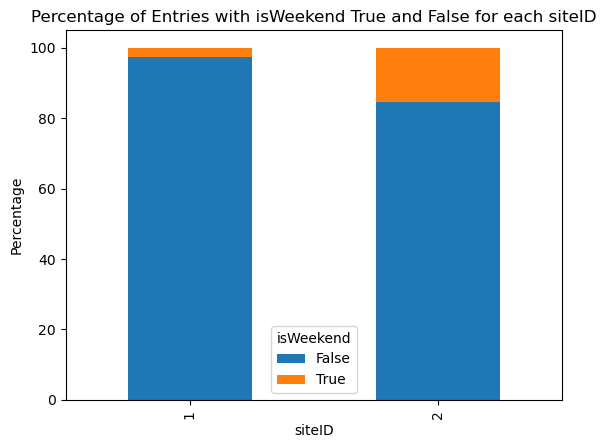

In [4]:
# A plot that shows the percentage of entries with isWeekend is true and false for each siteID (code generated with help of copilot)
# Prozentsatz der Einträge mit isWeekend True und False für jede siteID berechnen
%matplotlib inline
percentage_df = full_charging_df.groupby(['siteID', 'isWeekend']).size().unstack(fill_value=0)
percentage_df = percentage_df.div(percentage_df.sum(axis=1), axis=0) * 100

# Plot erstellen
percentage_df.plot(kind='bar', stacked=True)
plt.title('Percentage of Entries with isWeekend True and False for each siteID')
plt.xlabel('siteID')
plt.ylabel('Percentage')
plt.legend(title='isWeekend')
plt.show()

# Public site when ID is 2 and private site when ID is 1, 
# because if ID == 1 the liklyhood of charging sessions on the weekend is significantly lower so it is more likely a private site of a company
# New siteType column
full_charging_df["siteType"] = full_charging_df["siteID"].apply(lambda x: "Public" if x == 2 else "Private")